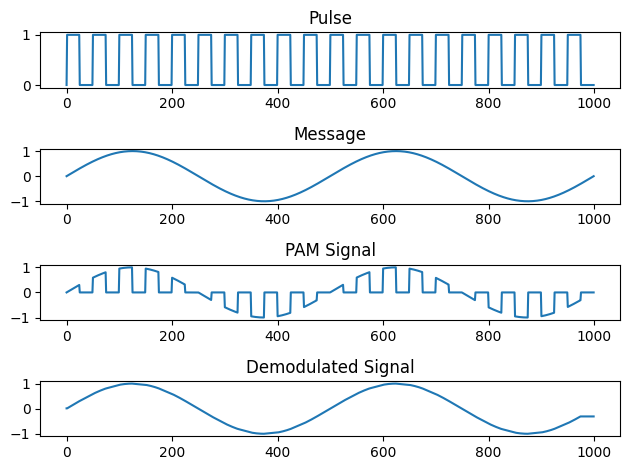

In [1]:
#1 and 5: (PAM) Modulation and Demodulation signal and analyze its waveform.
import numpy as np, matplotlib.pyplot as plt

t=np.linspace(0,1,1000)
m=np.sin(2*np.pi*2*t)                      # message
p=(np.sin(2*np.pi*20*t)>0).astype(int)     # pulse train
pam=m*p                                    # PAM signal

# demodulation (sample + interpolate)
i=np.where(p>0)[0]
d=np.interp(t,t[i],pam[i])

plt.subplot(4,1,1); plt.plot(p); plt.title("Pulse")
plt.subplot(4,1,2); plt.plot(m); plt.title("Message")
plt.subplot(4,1,3); plt.plot(pam); plt.title("PAM Signal")
plt.subplot(4,1,4); plt.plot(d); plt.title("Demodulated Signal")
plt.tight_layout(); plt.show()

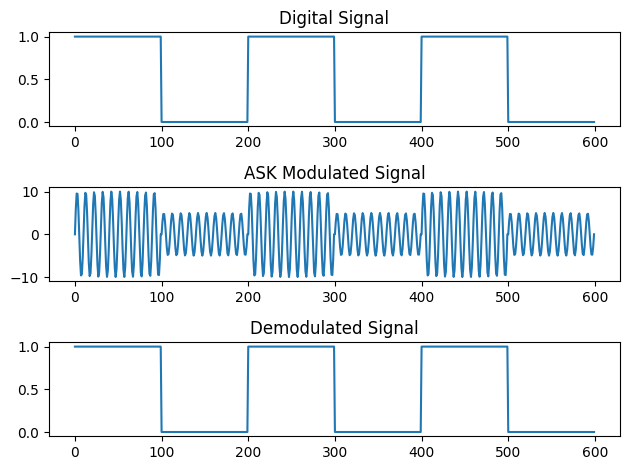

In [15]:
#2: ASK modulation Technique

import numpy as np
import matplotlib.pyplot as plt

b=[1,0,1,0,1,0]; n=100; t=np.linspace(0,1,n); c=np.sin(2*np.pi*10*t)
d=np.hstack([i*np.ones(n) for i in b])              # digital signal
m=np.hstack([(10 if i else 5)*c for i in b])                      # ASK modulation
r=np.array([1 if np.mean(abs(m[i*n:(i+1)*n]))>4.5 else 0 for i in range(len(b))])
rd=np.hstack([i*np.ones(n) for i in r])             # reconstructed signal

plt.subplot(3,1,1); plt.plot(d); plt.title("Digital Signal")
plt.subplot(3,1,2); plt.plot(m); plt.title("ASK Modulated Signal")
plt.subplot(3,1,3); plt.plot(rd); plt.title("Demodulated Signal")
plt.tight_layout(); plt.show()

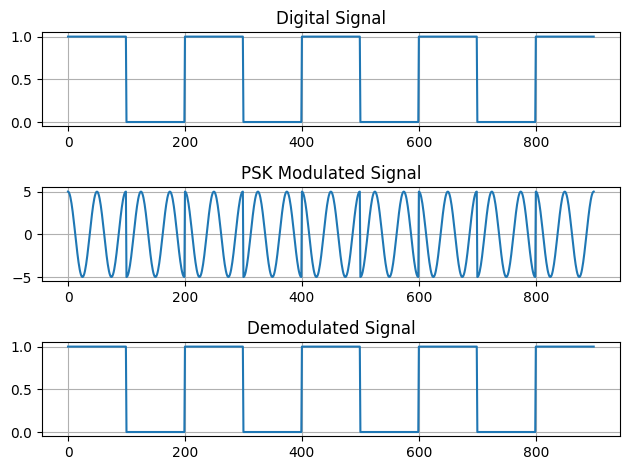

In [24]:
#PSK
import numpy as np, matplotlib.pyplot as plt

b=[1,0,1,0,1,0,1,0,1]; n=100; bp=1e-6
t1=np.linspace(0,bp*len(b),n*len(b))
d=np.repeat(b,n)


f=2/bp
t2=np.linspace(0,bp,n)


m=np.hstack([5*np.cos(2*np.pi*f*t2+(0 if i else np.pi)) for i in b])



ref=np.cos(2*np.pi*f*t2)
r=[1 if (2*np.trapezoid(m[i*n:(i+1)*n]*ref,t2)/bp)>0 else 0 for i in range(len(b))]
rd=np.repeat(r,n)


plt.subplot(3,1,1); plt.plot(d); plt.title("Digital Signal");plt.grid() 
plt.subplot(312); plt.plot(m); plt.title("PSK Modulated Signal");plt.grid()
plt.subplot(313); plt.plot(rd); plt.title("Demodulated Signal");plt.grid()

plt.tight_layout(); plt.show()

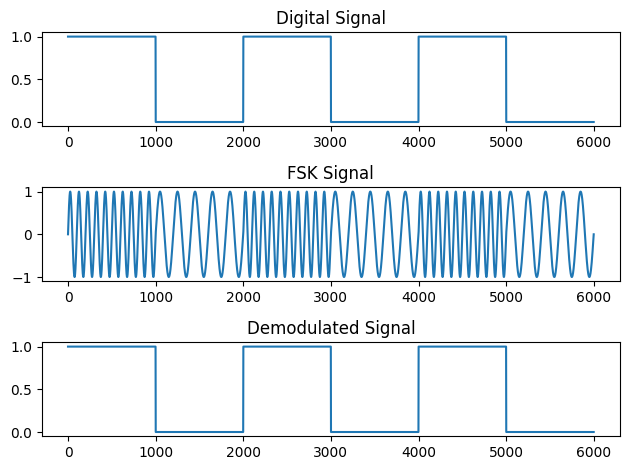

In [25]:
#LAB 4: FSK
import numpy as np, matplotlib.pyplot as plt

b=[1,0,1,0,1,0]; n=1000; t=np.linspace(0,1,n)
f1,f0=10,5

d=np.hstack([i*np.ones(n) for i in b])                         # digital signal
m=np.hstack([np.sin(2*np.pi*(f1 if i else f0)*t) for i in b])  # FSK signal

r=[1 if np.sum(m[i*n:(i+1)*n]*np.sin(2*np.pi*f1*t)) >
          np.sum(m[i*n:(i+1)*n]*np.sin(2*np.pi*f0*t)) else 0
   for i in range(len(b))]
rd=np.hstack([i*np.ones(n) for i in r])                        # demodulated

plt.subplot(3,1,1); plt.plot(d); plt.title("Digital Signal")
plt.subplot(3,1,2); plt.plot(m); plt.title("FSK Signal")
plt.subplot(3,1,3); plt.plot(rd); plt.title("Demodulated Signal")
plt.tight_layout(); plt.show()


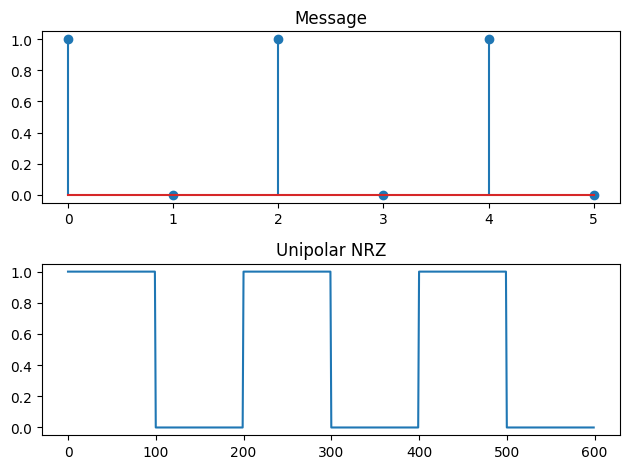

In [17]:
#5: Unipolar Non-Return-to-Zero (NRZ)
import numpy as np, matplotlib.pyplot as plt

b=[1,0,1,0,1,0]; s=np.repeat(b,100)

plt.subplot(2,1,1); plt.stem(b); plt.title("Message")
plt.subplot(2,1,2); plt.plot(s); plt.title("Unipolar NRZ")
plt.tight_layout(); plt.show()

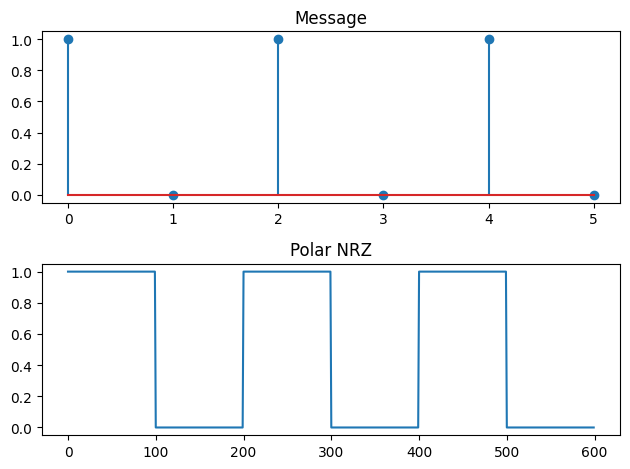

In [19]:
#6 :Polar Non-Return-to-Zero (NRZ)
import numpy as np, matplotlib.pyplot as plt

b=[1,0,1,0,1,0]; s=np.repeat(b,100)

plt.subplot(2,1,1); plt.stem(b); plt.title("Message")
plt.subplot(2,1,2); plt.plot(s); plt.title("Polar NRZ")
plt.tight_layout(); plt.show()

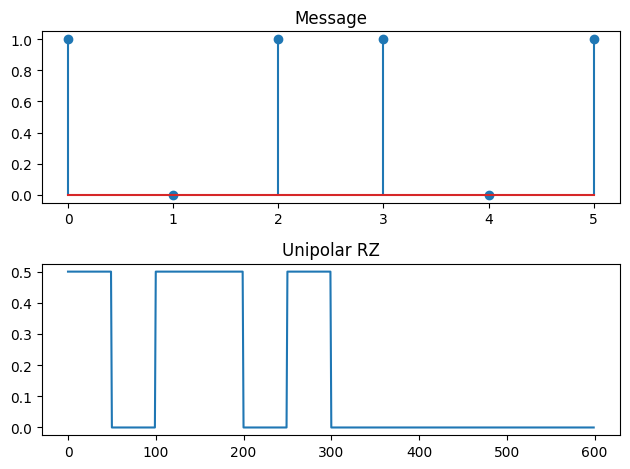

In [21]:
#U7: nipolar Return-to-Zero (RZ)
import numpy as np
import matplotlib.pyplot as plt

b = np.array([1,0,1,1,0,1])
# 1st half of each bit is high, 2nd half is zero
s = np.repeat(np.concatenate([b, np.zeros_like(b)]), 50) / 2  

plt.subplot(2,1,1)
plt.stem(b)                      
plt.title("Message")

plt.subplot(2,1,2)
plt.plot(s)
plt.title("Unipolar RZ")

plt.tight_layout()
plt.show()

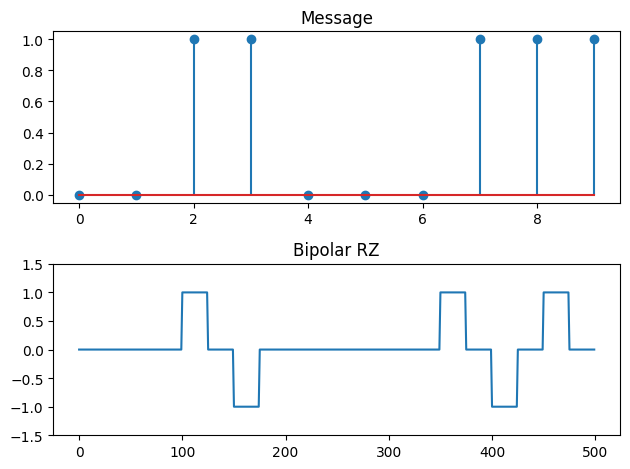

In [ ]:
#8:  Bipolar RZ
import numpy as np, matplotlib.pyplot as plt

b = np.array([0,0,1,1,0,0,0,1,1,1])
n = 50
s = np.zeros(len(b)*n)
l = 1
for i, bit in enumerate(b):
    if bit: s[i*n:i*n+n//2] = l; l*=-1
plt.subplot(2,1,1); plt.stem(b); plt.title("Message")
plt.subplot(2,1,2); plt.plot(s); plt.title("Bipolar RZ"); plt.ylim(-1.5,1.5)
plt.tight_layout(); plt.show()

[0 1 1 0 1 1 0 1 0 1]
[-1  1  1 -1  1 -1 -1  1  1 -1  1 -1 -1  1  1 -1 -1  1  1 -1]


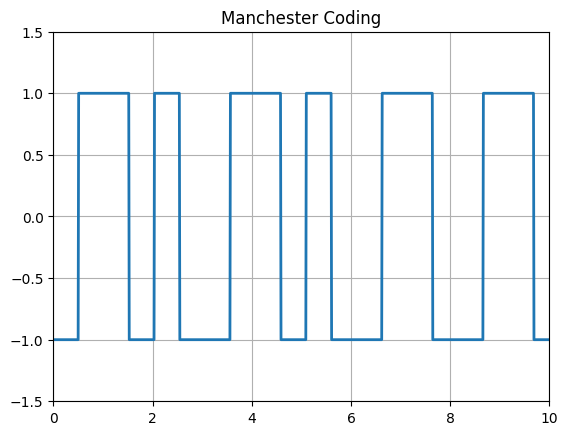

In [ ]:
# 9: Mancester 

import numpy as np
import matplotlib.pyplot as plt

N=10
n=np.random.randint(0,2,N)
print(n)

nnn=np.hstack([[1,-1] if b else [-1,1] for b in n])
print(nnn)

t=np.arange(0,N+0.01,0.01)
y=np.repeat(nnn,int(len(t)/len(nnn))+1)[:len(t)]

plt.plot(t,y,lw=2)
plt.axis([0,N,-1.5,1.5])
plt.grid()
plt.title("Manchester Coding")
plt.show()

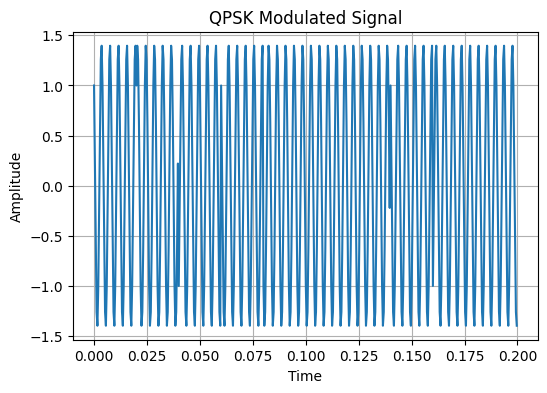

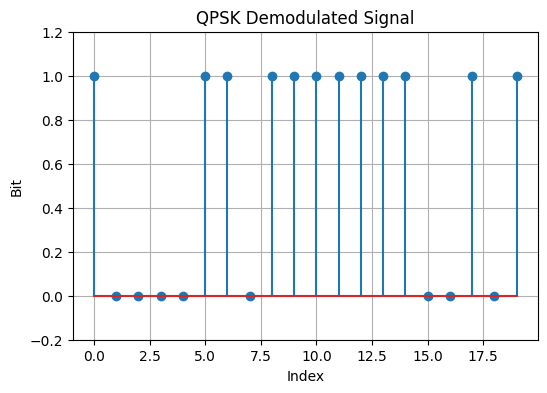

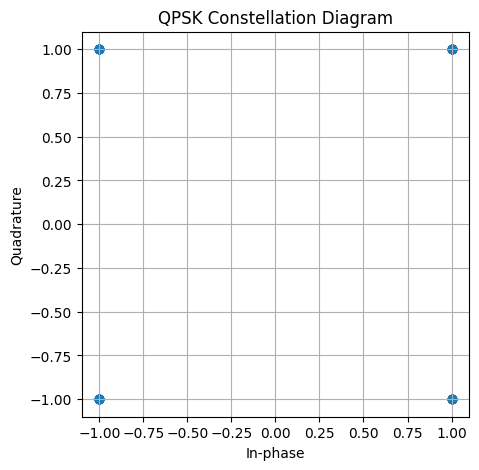

Original: [1 0 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1]
Demodulated: [1 0 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1]


In [ ]:
#QPSK Modulation And Demodulation

import numpy as np, matplotlib.pyplot as plt

d=np.random.randint(0,2,100); p=d.reshape(-1,2)
m={(0,0):1+1j,(0,1):-1+1j,(1,1):-1-1j,(1,0):1-1j}
s=np.array([m[tuple(b)] for b in p])

fc=5; n=50; t=np.arange(n)/n; sig=[]
for x in s: sig+=list(x.real*np.cos(2*np.pi*fc*t)+x.imag*np.sin(2*np.pi*fc*t))
sig=np.array(sig); ta=np.linspace(0,1,len(sig))

db=[]
for x in s:
    if x.real>0 and x.imag>0: db+=[0,0]
    elif x.real<0 and x.imag>0: db+=[0,1]
    elif x.real<0 and x.imag<0: db+=[1,1]
    else: db+=[1,0]
db=np.array(db)

plt.figure(figsize=(6,4)); plt.plot(ta[:500],sig[:500]); plt.title("QPSK Modulated Signal"); plt.xlabel("Time"); plt.ylabel("Amplitude"); plt.grid()
plt.figure(figsize=(6,4)); plt.stem(db[:20]); plt.title("QPSK Demodulated Signal"); plt.xlabel("Index"); plt.ylabel("Bit"); plt.ylim(-.2,1.2); plt.grid()
plt.figure(figsize=(5,5)); plt.scatter(s.real,s.imag); plt.title("QPSK Constellation Diagram"); plt.xlabel("In-phase"); plt.ylabel("Quadrature"); plt.grid()
plt.show()

print("Original:",d[:20]); print("Demodulated:",db[:20])

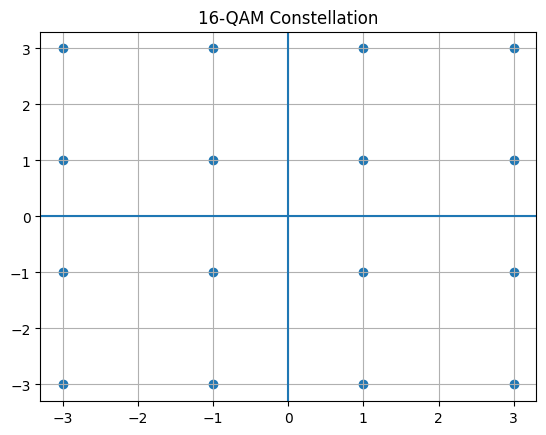

In [ ]:
#16 QAM
import numpy as np
import matplotlib.pyplot as plt

M=16
d=int(np.sqrt(M))
x=np.arange(-d+1,d,2)
I,Q=np.meshgrid(x,x)
s=I.flatten()+1j*Q.flatten()

plt.scatter(s.real,s.imag)
plt.axhline(0); plt.axvline(0)
plt.grid()
plt.title("16-QAM Constellation")
plt.show()

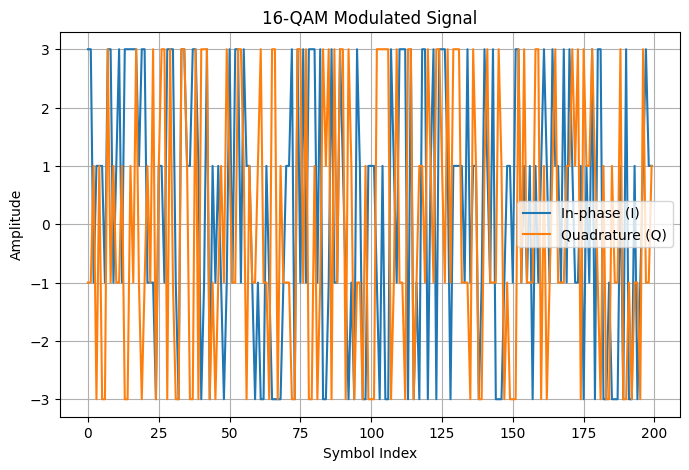

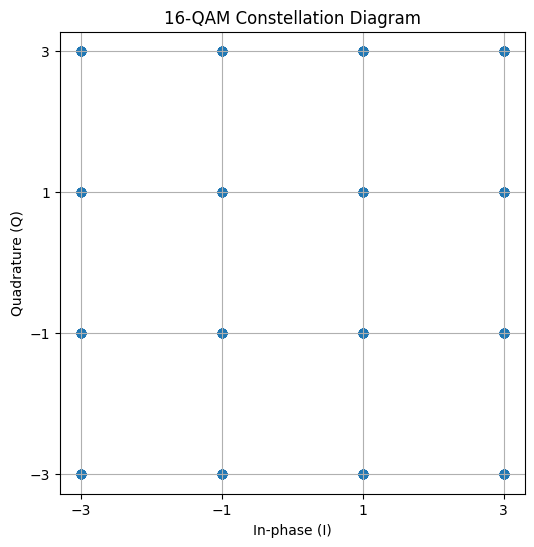

In [ ]:
# 16 QAM
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 200
mapping = {(0,0):-3, (0,1):-1, (1,1):1, (1,0):3}

# Generate and group bits
bits = np.random.randint(0, 2, N*4).reshape(N, 4)

# Map to I and Q components
I = np.array([mapping[tuple(b[:2])] for b in bits])
Q = np.array([mapping[tuple(b[2:])] for b in bits])

# Form 16-QAM signal
signal = I + 1j*Q
t = np.arange(N)

# -------- Modulated Signal --------
plt.figure(figsize=(8,5))
plt.plot(t, signal.real, label='In-phase (I)')
plt.plot(t, signal.imag, label='Quadrature (Q)')
plt.title("16-QAM Modulated Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

# -------- Constellation --------
plt.figure(figsize=(6,6))
plt.scatter(signal.real, signal.imag)
plt.title("16-QAM Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])
plt.axis('equal')
plt.grid()

plt.show()

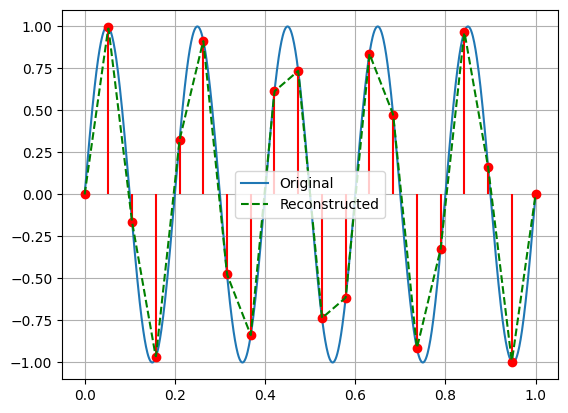

In [13]:
import numpy as np
import matplotlib.pyplot as plt

t=np.linspace(0,1,1000)
x=np.sin(2*np.pi*5*t)

ts=np.linspace(0,1,20)
xs=np.sin(2*np.pi*5*ts)

xr=np.interp(t,ts,xs)

plt.plot(t,x,label='Original')
plt.stem(ts,xs,linefmt='r-',markerfmt='ro',basefmt=' ')
plt.plot(t,xr,'g--',label='Reconstructed')
plt.legend(); plt.grid(); plt.show()

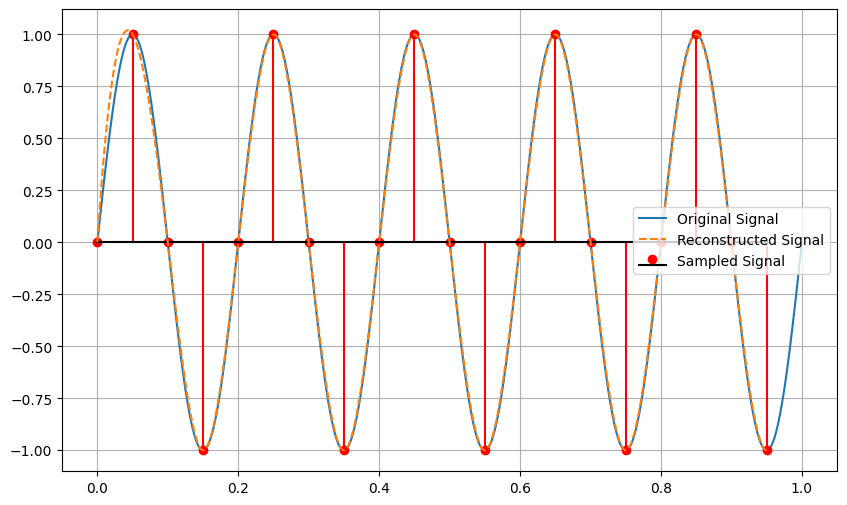

In [ ]:
#Sampling and Reconstruction of continous signal
import numpy as np, matplotlib.pyplot as plt
from scipy.interpolate import interp1d

t=np.linspace(0,1,1000); f=5; x=np.sin(2*np.pi*f*t)
fs=20; ts=np.arange(0,1,1/fs); xs=np.sin(2*np.pi*f*ts)

xr=interp1d(ts,xs,kind='cubic'); tr=np.linspace(0,ts.max(),1000); xr=xr(tr)

plt.figure(figsize=(10,6))
plt.plot(t,x,label="Original Signal")
plt.stem(ts,xs,linefmt='r-',markerfmt='ro',basefmt='k-',label="Sampled Signal")
plt.plot(tr,xr,'--',label="Reconstructed Signal")
plt.legend(); plt.grid(); plt.show()

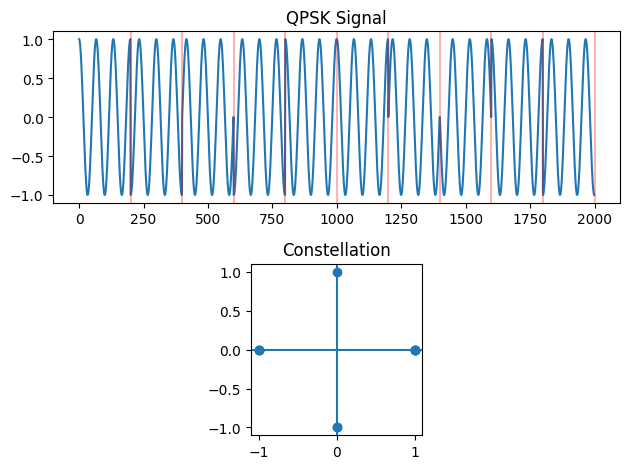

In [19]:
import numpy as np, matplotlib.pyplot as plt

# Random bits
b=np.random.randint(0,2,20)

# Time + storage
t=np.linspace(0,1,200); s=[]; idx=[]; I=[]; Q=[]

# QPSK mapping + signal
for i in range(0,len(b),2):
    p={(0,0):0,(0,1):np.pi/2,(1,1):np.pi,(1,0):3*np.pi/2}[tuple(b[i:i+2])]
    seg=np.cos(2*np.pi*3*t+p)
    s+=list(seg); idx.append(len(s))
    I.append(np.cos(p)); Q.append(np.sin(p))

# Waveform
plt.subplot(2,1,1)
plt.plot(s)
for i in idx: plt.axvline(i,color='r',alpha=.3)
plt.title("QPSK Signal")

# Constellation
plt.subplot(2,1,2)
plt.scatter(I,Q)
plt.axhline(0); plt.axvline(0)
plt.gca().set_aspect('equal')
plt.title("Constellation")

plt.tight_layout()
plt.show()

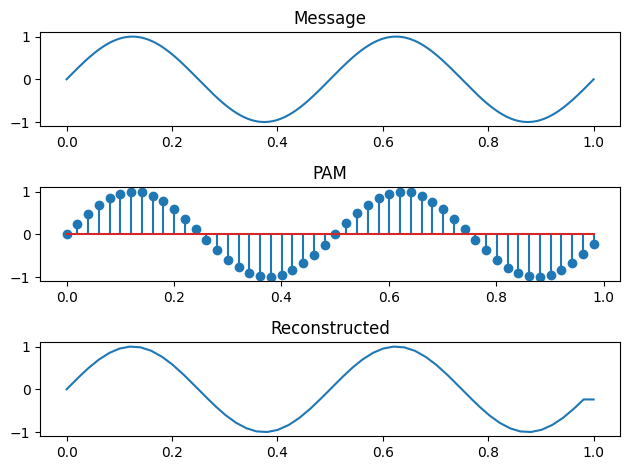

In [21]:
import numpy as np, matplotlib.pyplot as plt

t=np.linspace(0,1,1000); m=np.sin(2*np.pi*2*t)
s=m[::20]; tp=t[::20]
r=np.interp(t,tp,s)

plt.subplot(3,1,1); plt.plot(t,m); plt.title("Message")
plt.subplot(3,1,2); plt.stem(tp,s); plt.title("PAM")
plt.subplot(3,1,3); plt.plot(t,r); plt.title("Reconstructed")
plt.tight_layout(); plt.show()

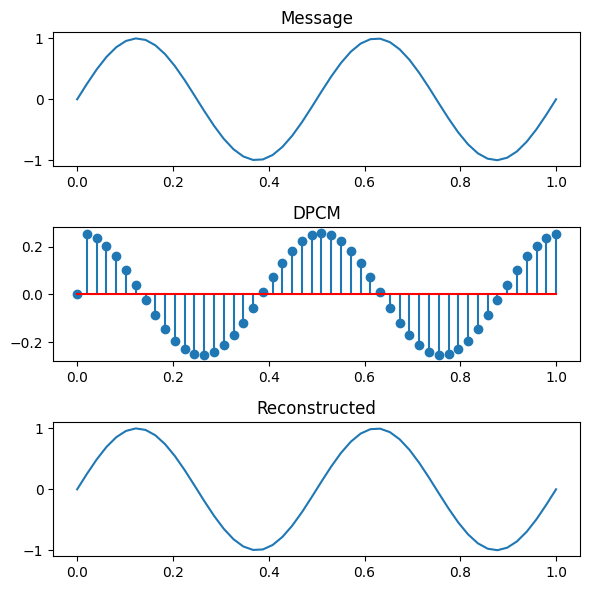

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Signal
t = np.linspace(0, 1, 50)
x = np.sin(2*np.pi*2*t)

# DPCM Encoding (difference)
d = np.zeros_like(x)
d[0] = x[0]
for i in range(1, len(x)):
    d[i] = x[i] - x[i-1]

# DPCM Decoding (reconstruction)
xr = np.zeros_like(x)
xr[0] = d[0]
for i in range(1, len(xr)):
    xr[i] = xr[i-1] + d[i]

# Plot
plt.figure(figsize=(6,6))
plt.subplot(3,1,1); plt.plot(t,x); plt.title("Message")
plt.subplot(3,1,2); plt.stem(t,d, basefmt="r"); plt.title("DPCM")
plt.subplot(3,1,3); plt.plot(t,xr); plt.title("Reconstructed")
plt.tight_layout(); plt.show()

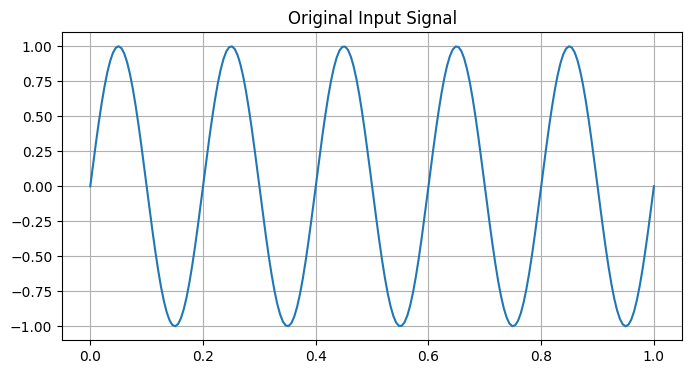

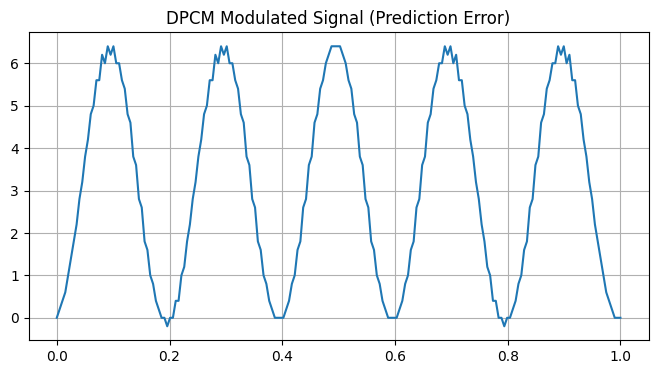

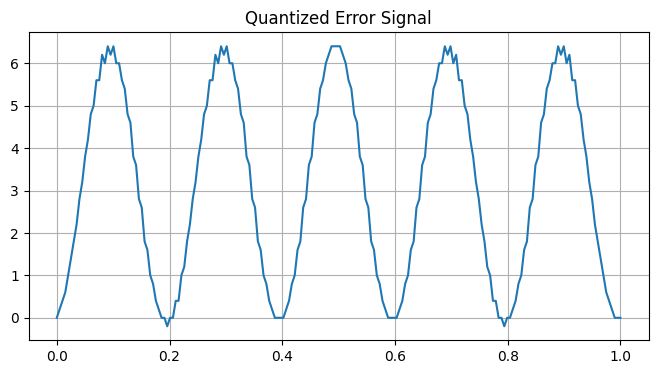

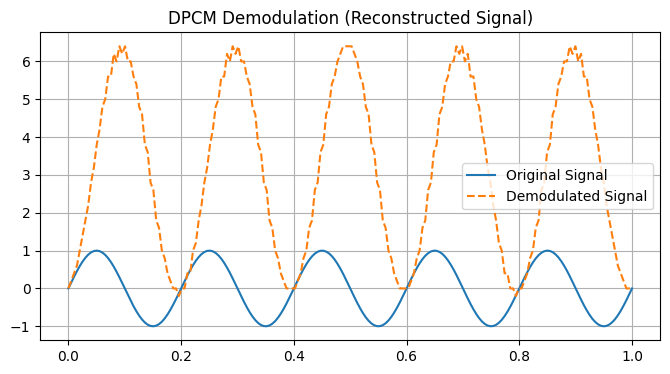

In [4]:
import numpy as np, matplotlib.pyplot as plt

t=np.linspace(0,1,200); x=np.sin(2*np.pi*5*t)
p=e=q=r=np.zeros(len(x)); s=0.2; r[0]=x[0]

for i in range(1,len(x)):
    p[i]=r[i-1]; e[i]=x[i]-p[i]; q[i]=s*np.round(e[i]/s)

for i in range(1,len(x)):
    r[i]=r[i-1]+q[i]

plt.figure(figsize=(8,4)); plt.plot(t,x); plt.title("Original Input Signal"); plt.grid()
plt.figure(figsize=(8,4)); plt.plot(t,e); plt.title("DPCM Modulated Signal (Prediction Error)"); plt.grid()
plt.figure(figsize=(8,4)); plt.plot(t,q); plt.title("Quantized Error Signal"); plt.grid()
plt.figure(figsize=(8,4)); plt.plot(t,x,label="Original Signal"); plt.plot(t,r,'--',label="Demodulated Signal")
plt.title("DPCM Demodulation (Reconstructed Signal)"); plt.legend(); plt.grid(); plt.show()